In [1]:
import redback 
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import Planck18 as cosmo 
import astropy.units as uu
from redback.transient_models.supernova_models import lambda_to_nu
import redback.interaction_processes as ip
import redback.sed as sed
import redback.photosphere as photosphere

import astropy.units as uu

import extinction
from extinction import ccm89, fitzpatrick99, apply, remove
from scipy.interpolate import RegularGridInterpolator
import sncosmo

def sn1998bw_template(time, redshift, amplitude, **kwargs):
    """
    A wrapper to the SN1998bw template. Only valid between 1100-11000 Angstrom and 0.01 to 90 days post explosion in rest frame

    Parameters
    ----------
    time
        time in days in observer frame (post explosion)
    redshift
        redshift
    amplitude
        amplitude scaling factor, where 1.0 is the original brightness of SN1998bw; and f_lambda is scaled by this factor
    kwargs
        Additional keyword arguments required by redback.
    frequency
        Required if output_format is 'flux_density'. frequency to calculate - Must be same length as time array or a single number).
    bands
        Required if output_format is 'magnitude' or 'flux'.
    output_format
        'flux_density', 'magnitude', 'spectra', 'flux', 'sncosmo_source'
    cosmology
        Cosmology to use for luminosity distance calculation. Defaults to Planck18. Must be a astropy.cosmology object.
    Returns
    -------
        set by output format - 'flux_density', 'magnitude', 'spectra', 'flux', 'sncosmo_source'

    """
    import sncosmo
    model = sncosmo.Model(source='v19-1998bw')
    original_redshift = 0.0085
    cosmology = kwargs.get("cosmology", cosmo)
    original_dl = (43*uu.Mpc).to(uu.cm).value

    # From roughly matching to Galama+ or Clocchiatti+1998bw light curves
    original_peak_time = 15
    model.set(z=original_redshift, t0=original_peak_time)
    model.set_source_peakmag(14.25, band='bessellb', magsys='ab')
    tts = np.geomspace(0.01, 90, 200)
    lls = np.linspace(1620, 11000, 300)
    f_lambda = model.flux(tts, lls) #erg/s/cm^2/Angstrom.
    l_lambda = f_lambda * 4 * np.pi * original_dl**2  # erg/s/Angstrom

    # We consider this the rest frame spectrum of 1998bw. Now we can redshift it and scale it.
    time_obs = tts * (1 + redshift)
    lambda_obs = lls * (1 + redshift)
    dl_new = cosmology.luminosity_distance(redshift).cgs.value
    f_lambda_obs = l_lambda / (4 * np.pi * dl_new**2)
    f_lambda_obs = amplitude * f_lambda_obs * (1 + redshift) # accounting for bandwidth stretching
    f_lambda_obs = f_lambda_obs * uu.erg / uu.s / uu.cm ** 2 / uu.Angstrom
    if kwargs['output_format'] == 'flux_density':
        frequency = kwargs['frequency']
        # work in obs frame
        ff_array = lambda_to_nu(lambda_obs)

        # Convert flux density to mJy
        fmjy = f_lambda_obs.to(uu.mJy, equivalencies=uu.spectral_density(wav=lambda_obs * uu.Angstrom)).value
        # Create interpolator on obs frame grid
        flux_interpolator = RegularGridInterpolator(
            (time_obs, ff_array),
            fmjy,
            bounds_error=False,
            fill_value=0.0)

        # Prepare points for interpolation
        if isinstance(frequency, (int, float)):
            frequency = np.ones_like(time) * frequency

        # Create points for evaluation
        points = np.column_stack((time, frequency))

        # Return interpolated flux density with (1+z) correction for observer frame
        return flux_interpolator(points)
    elif kwargs['output_format'] == 'spectra':
        return namedtuple('output', ['time', 'lambdas', 'spectra'])(time=time_obs,
                                                                    lambdas=lambda_obs,
                                                                    spectra=f_lambda_obs)
    else:
        return sed.get_correct_output_format_from_spectra(time=time, time_eval=time_obs,
                                                          spectra=f_lambda_obs, lambda_array=lambda_obs,
                                                          **kwargs)


# After pasting the function definition into your cell:
from redback.model_library import all_models_dict

all_models_dict['sn1998bw_template'] = sn1998bw_template

# Now any redback functions that look in the dictionary will find it!

No module named 'lalsimulation'
lalsimulation is not installed. Some EOS based models will not work. Please use bilby eos or pass your own EOS generation class to the model
16:38 bilby INFO    : Running bilby version: 2.3.0
16:38 redback INFO    : Running redback version: 1.12.1


In [2]:
# #INFO FOR GRB 100316D
# #from jillian: 
# #dt_days,filter,tel,mag,mag_err
# #19.53004,r,GROND,20.36,0.05
# time = np.array(19.53004)
# red = 0.0591
# freq = 4.85800e+14 # r band 

# sn_1998b2 = func(time=time,redshift=red,amplitude=1.0,frequency=freq,output_format='flux_density', cosmology=cosmo) #arbitrary GRB -- one to take interpolation over !! 
# sn_1998b1 = func(time=time,redshift=0.0085,amplitude=1.0,frequency=freq,output_format='flux_density', cosmology=cosmo) #sn 1998bw 

# print(sn_1998b2, sn_1998b1, sn_1998b2/sn_1998b1)

# #f_98 for 100316D according to andrew = 0.5 but i get 0.02 :/ 

# #if we choose an earlier time does this change ?  
# #this says flux density of GRB event = 0.25420234 mJy 
# #we calculate it in below cell to be = 0.02606 mJy



In [3]:
# #how does this compare to me converting the flux density -- is it something wrong with my flux density conversion method? 
# event_name = '100316D'
# red = 0.0591
# epoch = np.array(19.53004) #lowest possible time - short GRB - increase to 0.1
# frequency = 4.85800e+14 #match freq to redback filter band 
# AB_mag = 20.36 
# a_v = 0.36 #correct from literaute ? 
# wavelength= np.array([6175.58000]) #angstroms 

# #only need wavleength to do the flux density conversion !! if model does this for us then dont need it !! 

# #convert AB magnitude of arbitrary GRB event --> flux density (mJy)
# def calc_flux_density_from_ABmag(AB_mag):
#     """
#     Calculate flux density from AB magnitude assuming monochromatic AB filter

#     :param magnitudes: AB magnitude values
#     :return: flux density
#     """
#     return (AB_mag * uu.ABmag).to(uu.mJy)

# flux_density_event = calc_flux_density_from_ABmag(AB_mag)
# print("This is the flux density of  GRB event", event_name ,f"without extinction correction: {flux_density_event:.5f}")

# #de-redden flux density, account for extinction if necessary 
# dereddened_flux_event = extinction.remove(fitzpatrick99(wavelength, a_v, 3.1),flux_density_event)
# print(f"This is the extinction corrected GRB event flux density found using fitzpatrick99: {dereddened_flux_event[0]:.5f}")


# time = epoch #worked for np.array([11]) so works for all other times ?
# red = red #redshift of 231117A
# freq = frequency

# sn_1998b1 = func(time=time,redshift=0.0085,amplitude=1.0,frequency=freq,output_format='flux_density', cosmology=cosmo) #SN1998bw


# #extinction corrected flux frac: 
# print(f"{dereddened_flux_event[0]:.5f}", sn_1998b1, dereddened_flux_event[0]/sn_1998b1)

# #why does andrew have 0.5 ? 

In [4]:
# time = epoch #worked for np.array([11]) so works for all other times ?
# red = red #redshift of 231117A
# freq = frequency

# sn_1998b2 = func(time=time,redshift=red,amplitude=1.0,frequency=freq,output_format='flux_density', cosmology=cosmo) #artibtrary GRB -- interpolated line !! one to compare and take ratio over !! 
# sn_1998b1 = func(time=time,redshift=0.0085,amplitude=1.0,frequency=freq,output_format='flux_density', cosmology=cosmo) #SN1998bw

# #which result is more similar to andrew ? 
# #using model - no extinction 
# print(sn_1998b2, sn_1998b1, sn_1998b2/sn_1998b1)

In [5]:
# # 1. Your hand-calculated flux (Observed)
# flux_density_event = calc_flux_density_from_ABmag(20.36) 
# # Note: Use the actual A_V for 100316D here!
# dereddened_flux_event = extinction.remove(fitzpatrick99(wavelength, 0.36, 3.1), flux_density_event)

# # 2. The Model Prediction (Theoretical Baseline)
# # We put SN1998bw at the SAME redshift as the GRB
# sn_at_grb_z = func(time=epoch, 
#                    redshift=0.0591, 
#                    amplitude=1.0, 
#                    frequency=frequency, 
#                    output_format='flux_density')

# # 3. The Ratio
# ratio = dereddened_flux_event[0] / sn_at_grb_z
# print(f"The event is {ratio[0]:.2f} times the brightness of SN1998bw")

In [6]:
# #correct approach : 
# event_name = '100316D'
# red = 0.0591
# epoch = np.array(19.53004) #lowest possible time - short GRB - increase to 0.1
# frequency = 4.85800e+14 #match freq to redback filter band 
# AB_mag = 20.36 
# a_v = 0.12 * 3.1
# wavelength= np.array([6175.58000]) #angstroms 

# #convert AB magnitude of arbitrary GRB event --> flux density (mJy)
# def calc_flux_density_from_ABmag(AB_mag):
#     """
#     Calculate flux density from AB magnitude assuming monochromatic AB filter

#     :param magnitudes: AB magnitude values
#     :return: flux density
#     """
#     return (AB_mag * uu.ABmag).to(uu.mJy)

# flux_density_event = calc_flux_density_from_ABmag(AB_mag)
# print("This is the flux density of  GRB event", event_name ,f"without extinction correction: {flux_density_event:.5f}")

# #de-redden flux density, account for extinction if necessary 
# dereddened_flux_event = extinction.remove(fitzpatrick99(wavelength, a_v, 3.1),flux_density_event)
# print(f"This is the extinction corrected GRB event flux density found using fitzpatrick99: {dereddened_flux_event[0]:.5f}")


# #SN1998bw interpolation
# sn_1998b2 = func(time=time,redshift=red,amplitude=1.0,frequency=freq,output_format='flux_density', cosmology=cosmo)

# #final values
# print(sn_1998b2, dereddened_flux_event[0], dereddened_flux_event[0]/sn_1998b2)

# #this should be close to 0.5 ??? use a different datapoint to check 

# #check this method with how i did 980425 !! 



In [7]:
#new method

#get times as close to 37 days or 10.42 days as possible ? 

#take late time obs preferrable in B band from Jillian data 
#25.508225000000003,r,GROND,20.78,0.03

#10.477985,r,GROND,19.91,0.03

#very late time? 
#40.484669999999994,r,GROND,21.83,0.06
# time = np.array((40.484669999999994)) #days post explosion -- too early of a time ? 
# red = 0.0591
# AB_mag = 21.83 #r band filter 
# target_frequencies = 4.85800e+14 # r band Hz
# wavelength = np.array([6175.58000])
# target_milky_way_ebv = 0.012 #from literature 


#ATTEMPT 2: using the latest time: !!!!! NOTE: not incuding any errors on the magnitudes 
#83.441095,r,GROND,23.66,0.23
time = np.array((83.441095)) #days post explosion -- too early of a time ? 
red = 0.0591
AB_mag = 23.66 #r band filter 
target_frequencies = 4.85800e+14 # r band Hz
wavelength = np.array([6175.58000])
target_milky_way_ebv = 0.012 #from literature 

a_v = target_milky_way_ebv  * 3.1

#WITH GAVINS IMPROVED FUNCTION: 

all_models_dict['sn1998bw_template'] = sn1998bw_template

func1 = all_models_dict['sn1998bw_template']

sn_1998bw1= func1(time=time,
                 redshift=red, #redshift of actual event 
                 model_kwargs=None,
                 amplitude = 1,
                 output_format='flux_density', # Returns mJy
                 frequency=target_frequencies,
                 mw_extinction=True,
                 # Add MW dust for YOUR target
                 ebv_mw=target_milky_way_ebv, # Specific to your GRB location
                 model_kwarg_names=[],
                 use_set_peak_magnitude = True,
                 peak_abs_mag = -18.6, #-18.88 B band ? 
                 peak_time = 16 #shifts pak time to where it actually is
                 )

#calculate dereddened flux density of GRB evnet: 
def calc_flux_density_from_ABmag(AB_mag):
    """
    Calculate flux density from AB magnitude assuming monochromatic AB filter

    :param magnitudes: AB magnitude values
    :return: flux density
    """
    return (AB_mag * uu.ABmag).to(uu.mJy)

flux_density_event = calc_flux_density_from_ABmag(AB_mag)
print(f"This is the flux density of  GRB event without extinction correction: {flux_density_event:.5f}")

#de-redden flux density, account for extinction if necessary 
dereddened_flux_event = extinction.remove(fitzpatrick99(wavelength, a_v, 3.1),flux_density_event) 
print(f"This is the extinction corrected GRB event flux density found using fitzpatrick99: {dereddened_flux_event[0]:.5f}")

#calculate and print final ratio 
flux_ratio = dereddened_flux_event / sn_1998bw1
print(flux_ratio[0])

#VERY WRONG ? -- if still wrong show whatsgoing on on a plot ! i get 0.05 ?? varies a lot ?? 


This is the flux density of  GRB event without extinction correction: 0.00125 mJy
This is the extinction corrected GRB event flux density found using fitzpatrick99: 0.00128 mJy
0.10979020534710522 mJy


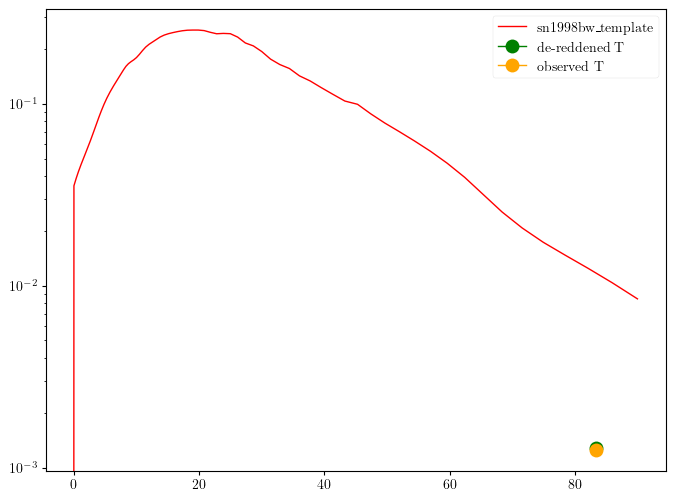

In [8]:
times = np.geomspace(0.01,90,200)

sn_1998bw1= func1(time=times,
                 redshift=red,
                 model_kwargs=None,
                 amplitude = 1,
                 output_format='flux_density', # Returns mJy
                 frequency=target_frequencies,
                 mw_extinction=True,
                 # Add MW dust for YOUR target
                 ebv_mw=target_milky_way_ebv, # Specific to your GRB location
                 model_kwarg_names=[],
                 use_set_peak_magnitude = True,
                 peak_abs_mag = -18.6, #-18.88 B band ? 
                 peak_time = 16 #shifts pak time to where it actually is
                 )

#make new functions for specific times to bcompare the baseline points on the plot


plt.figure(figsize = (8,6))
plt.semilogy(times,sn_1998bw1, '-r', label = 'sn1998bw_template')
#how do i get these other values to work ?? 
plt.semilogy(time, dereddened_flux_event[0], marker='o',color='green', markersize = 10, label = 'de-reddened T') #dereddened flux density points for GRB event 
plt.semilogy(time, flux_density_event, marker='o',color='orange', markersize = 10, label = 'observed T ') #observed (reddened) flux density points for GRB event -- issue with this point -- re run ? -- fixed !! 
plt.legend()
plt.show()